In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

root = "/content/drive/MyDrive/AutoOpt/dataset_5"

data = []

for algo in os.listdir(root):
    algo_path = os.path.join(root, algo)

    for fname in os.listdir(algo_path):
        if fname.endswith(".png"):
            parts = fname.replace(".png", "").split("_")

            algorithm = parts[0]   # CMAES
            problem = parts[1]     # f1
            run = parts[2]         # run00

            data.append({
                "path": os.path.join(algo_path, fname),
                "algorithm": algorithm,
                "problem": problem,
                "run": run
            })

In [4]:
import random
from collections import defaultdict

def get_problem_group(problem_str):
    num = int(problem_str[1:]) # Extract the number from 'fN'
    if 1 <= num <= 5: return 'G1'
    elif 6 <= num <= 9: return 'G2'
    elif 10 <= num <= 14: return 'G3'
    elif 15 <= num <= 19: return 'G4'
    elif 20 <= num <= 24: return 'G5'
    return 'other' # Should not happen for standard BBOB problems

# Get all unique problem identifiers
all_problems_list = sorted(list(set(item["problem"] for item in data)))
random.shuffle(all_problems_list) # Shuffle once for initial randomness

# Group problems by their defined categories
grouped_problems = defaultdict(list)
for p in all_problems_list:
    group = get_problem_group(p)
    grouped_problems[group].append(p)

# Shuffle problems within each group to ensure random selection when popping
for group_name in grouped_problems:
    random.shuffle(grouped_problems[group_name])

# Initialize lists for problems assigned to each split
train_problems = []
val_problems = []
test_problems = []

# Perform stratified selection: one problem from each group for each split
# This ensures each of the 5 groups is represented in train, val, and test.
# And, since there are 5 groups, this fulfills the requirement of 5 problems for val/test.
for group_name in sorted(grouped_problems.keys()): # Iterate through groups consistently
    current_group_problems = grouped_problems[group_name]

    # Ensure we have enough problems in the group to assign one to each split
    # All BBOB groups G1, G3, G4, G5 have 5 problems, G2 has 4, so all have >=3
    if len(current_group_problems) >= 3:
        train_problems.append(current_group_problems.pop())
        val_problems.append(current_group_problems.pop())
        test_problems.append(current_group_problems.pop())
    elif len(current_group_problems) == 2:
        # Fallback if a group only has 2 problems (e.g., assign to train and val)
        train_problems.append(current_group_problems.pop())
        val_problems.append(current_group_problems.pop())
    elif len(current_group_problems) == 1:
        # Fallback if a group only has 1 problem (e.g., assign to train)
        train_problems.append(current_group_problems.pop())

# Collect all remaining problems after the stratified selection
remaining_problems = []
for group_name in grouped_problems:
    remaining_problems.extend(grouped_problems[group_name])

random.shuffle(remaining_problems)

# Assign all remaining problems to the training set
# (val_problems and test_problems already have 5 problems each from stratified selection)
train_problems.extend(remaining_problems)

# Create sets for faster lookup during data assignment
train_problems_set = set(train_problems)
val_problems_set = set(val_problems)
test_problems_set = set(test_problems)

splits = {"train": [], "val": [], "test": []}

# Assign items to splits based on their problem identifier
for item in data:
    if item["problem"] in train_problems_set:
        splits["train"].append(item)
    elif item["problem"] in val_problems_set:
        splits["val"].append(item)
    elif item["problem"] in test_problems_set:
        splits["test"].append(item)
    else:
        print(f"Warning: Problem {item['problem']} not assigned to any split.")

print(f"Train problems ({len(train_problems)}): {sorted(train_problems)}")
print(f"Validation problems ({len(val_problems)}): {sorted(val_problems)}")
print(f"Test problems ({len(test_problems)}): {sorted(test_problems)}")

Train problems (14): ['f1', 'f11', 'f12', 'f14', 'f16', 'f17', 'f19', 'f2', 'f20', 'f21', 'f24', 'f3', 'f7', 'f9']
Validation problems (5): ['f10', 'f15', 'f22', 'f4', 'f6']
Test problems (5): ['f13', 'f18', 'f23', 'f5', 'f8']


In [5]:
from torch.utils.data import Dataset
from PIL import Image

class BBOBDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

        # map algorithms to indices
        algos = sorted(list(set(i["algorithm"] for i in items)))
        self.label_map = {a: idx for idx, a in enumerate(algos)}

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]

        image = Image.open(item["path"]).convert("L")  # grayscale
        label = self.label_map[item["algorithm"]]

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = BBOBDataset(splits["train"], transform)
val_dataset   = BBOBDataset(splits["val"], transform)
test_dataset  = BBOBDataset(splits["test"], transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [7]:
print(len(train_dataset), len(val_dataset), len(test_dataset))
x, y = train_dataset[0]
x2, y2 = val_dataset[1]
print(x.shape)  # should be (1, H, W)

2100 750 750
torch.Size([1, 128, 128])


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # 1st conv block
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)

        # 2nd conv block
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        # 3rd conv block
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # after 3 pools: 128 → 64 → 32 → 16
        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Conv block 1
        x = self.pool(F.relu(self.conv1(x)))  # 128 → 64

        # Conv block 2
        x = self.pool(F.relu(self.conv2(x)))  # 64 → 32

        # Conv block 3
        x = self.pool(F.relu(self.conv3(x)))  # 32 → 16

        # Flatten
        x = torch.flatten(x, 1)

        # Dense layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        # IMPORTANT:
        # no softmax here if using CrossEntropyLoss
        return x



In [9]:
from torch.utils.data import DataLoader
num_epochs = 20;
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)


model = CNN(num_classes=5)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

val_losses_history = [] # To store validation loss for each epoch

for epoch in range(num_epochs):

    # -------- TRAIN --------
    model.train()
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()


    # -------- VALIDATION --------
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    val_losses_history.append(val_loss) # Store the validation loss
    print(f"Epoch {epoch}, Val Loss: {val_loss}")

Epoch 0, Val Loss: 22.311518967151642
Epoch 1, Val Loss: 8.06057921051979
Epoch 2, Val Loss: 3.6427273228764534
Epoch 3, Val Loss: 6.5964822471141815
Epoch 4, Val Loss: 5.377246955380542
Epoch 5, Val Loss: 2.824834430241026
Epoch 6, Val Loss: 2.874871587380767
Epoch 7, Val Loss: 2.564598052529618
Epoch 8, Val Loss: 2.611674588173628
Epoch 9, Val Loss: 1.9000955793017056
Epoch 10, Val Loss: 2.7751434799283743
Epoch 11, Val Loss: 1.7939555000484688
Epoch 12, Val Loss: 2.863599324081406
Epoch 13, Val Loss: 3.5614004991948605
Epoch 14, Val Loss: 1.9483102430822328
Epoch 15, Val Loss: 2.388937993440777
Epoch 16, Val Loss: 1.8992728328157682
Epoch 17, Val Loss: 1.931129152100766
Epoch 18, Val Loss: 2.0611579664691817
Epoch 19, Val Loss: 2.2028091540705645


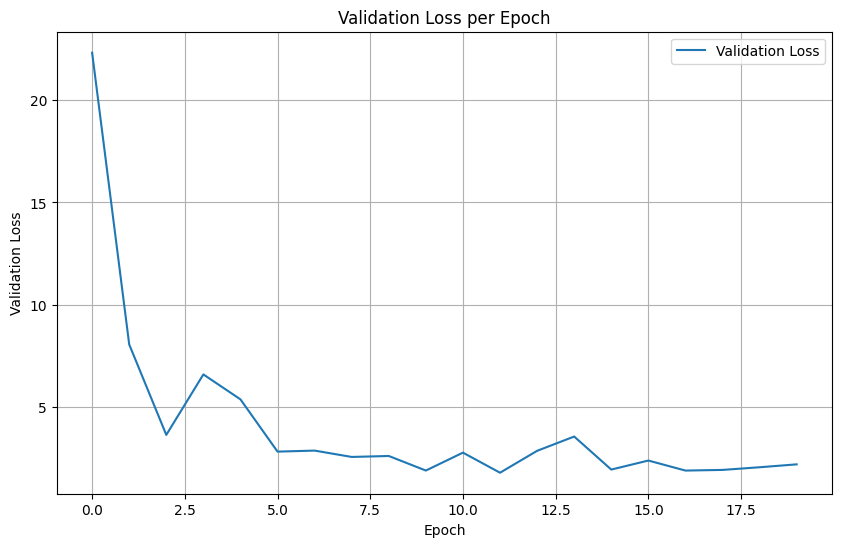

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), val_losses_history, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss per Epoch')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
test_loader  = DataLoader(test_dataset, batch_size=32)
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for x, y in test_loader:
        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[148   1   0   1   0]
 [  0 119  31   0   0]
 [  1   4 118   8  19]
 [  1   0   0 149   0]
 [  0   0  11   0 139]]


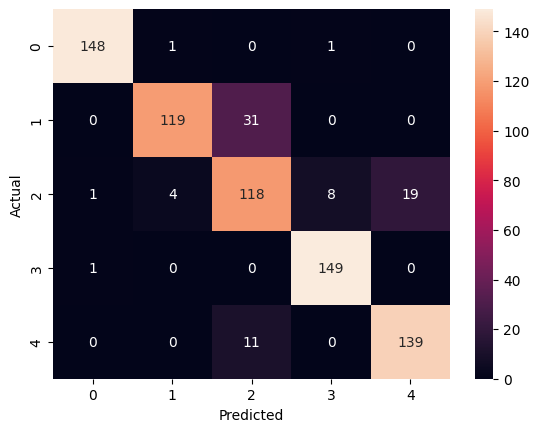

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
import numpy as np

per_class_acc = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(per_class_acc):
    print(f"Class {i}: {acc:.3f}")

Class 0: 0.987
Class 1: 0.793
Class 2: 0.787
Class 3: 0.993
Class 4: 0.927


In [18]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(y_true, y_pred, average='macro')
print("Macro F1:", macro_f1)

Macro F1: 0.8973399996126628


In [19]:
pairs = []

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j:
            pairs.append((cm[i, j], i, j))

pairs.sort(reverse=True)

print("Most confused pairs:")
for count, true_c, pred_c in pairs[:5]:
    print(f"True {true_c} → Pred {pred_c}: {count}")

Most confused pairs:
True 1 → Pred 2: 31
True 2 → Pred 4: 19
True 4 → Pred 2: 11
True 2 → Pred 3: 8
True 2 → Pred 1: 4


In [20]:
print("Algorithm Index to Name Mapping:")
# Reverse the label_map to show index -> algorithm name
index_to_algo = {idx: algo for algo, idx in train_dataset.label_map.items()}
for i in range(len(index_to_algo)):
    print(f"Class {i}: {index_to_algo[i]}")

Algorithm Index to Name Mapping:
Class 0: CMAES
Class 1: DE
Class 2: PSO
Class 3: RandomSearch
Class 4: SimulatedAnnealing


In [21]:
import os
from torch.utils.data import DataLoader
from torchvision import transforms
import torch
from sklearn.metrics import confusion_matrix, f1_score
import numpy as np

# Custom BBOBDataset to use a predefined label_map, ensuring consistency with the trained model
class BBOBDatasetWithFixedLabelMap(BBOBDataset):
    def __init__(self, items, transform=None, label_map=None):
        # Initialize the base BBOBDataset, which would normally create its own label_map
        super().__init__(items, transform)
        if label_map is not None:
            # Override the internally generated label_map with the provided one
            self.label_map = label_map
        # If label_map is None, it falls back to the original BBOBDataset behavior

# Function to load data from a given root path
def load_dataset_info(root_path):
    dataset_info = []
    if not os.path.exists(root_path):
        print(f"Warning: Path does not exist: {root_path}")
        return dataset_info

    for algo in os.listdir(root_path):
        algo_path = os.path.join(root_path, algo)
        if os.path.isdir(algo_path):
            for fname in os.listdir(algo_path):
                if fname.endswith(".png"):
                    parts = fname.replace(".png", "").split("_")
                    if len(parts) >= 3:
                        algorithm = parts[0]
                        problem = parts[1]
                        run = parts[2]
                        dataset_info.append({
                            "path": os.path.join(algo_path, fname),
                            "algorithm": algorithm,
                            "problem": problem,
                            "run": run
                        })
    return dataset_info

# Define the new dataset roots
unimodal_root = "/content/drive/MyDrive/AutoOpt/dataset_30_unimodal"
multimodal_root = "/content/drive/MyDrive/AutoOpt/dataset_30_multimodal"

# Load data for both new datasets
print(f"Loading data for unimodal dataset from: {unimodal_root}")
data_unimodal_30 = load_dataset_info(unimodal_root)
print(f"Loaded {len(data_unimodal_30)} items for unimodal dataset.")

print(f"Loading data for multimodal dataset from: {multimodal_root}")
data_multimodal_30 = load_dataset_info(multimodal_root)
print(f"Loaded {len(data_multimodal_30)} items for multimodal dataset.")

# Ensure `train_dataset` and `transform` are available from previous cells
if 'train_dataset' in globals() and 'transform' in globals():
    # Create BBOBDataset instances for the new datasets using the fixed label map
    unimodal_30_dataset = BBOBDatasetWithFixedLabelMap(data_unimodal_30, transform, label_map=train_dataset.label_map)
    multimodal_30_dataset = BBOBDatasetWithFixedLabelMap(data_multimodal_30, transform, label_map=train_dataset.label_map)

    print("Unimodal 30 dataset label map:", unimodal_30_dataset.label_map)
    print("Multimodal 30 dataset label map:", multimodal_30_dataset.label_map)
    print("Original train dataset label map:", train_dataset.label_map)

    # Create DataLoaders for the new datasets
    unimodal_30_loader = DataLoader(unimodal_30_dataset, batch_size=32)
    multimodal_30_loader = DataLoader(multimodal_30_dataset, batch_size=32)

    # Assume `model` is already trained and available from previous cells
    if 'model' not in globals():
        print("Error: Trained model not found. Please ensure the model training cells have been run.")
    else:
        model.eval() # Set model to evaluation mode

        # --- Evaluate Unimodal 30 Dataset ---
        print("\n--- Evaluating Unimodal 30 Dataset ---")
        y_true_unimodal = []
        y_pred_unimodal = []
        with torch.no_grad():
            for x, y in unimodal_30_loader:
                outputs = model(x)
                preds = torch.argmax(outputs, dim=1)
                y_true_unimodal.extend(y.cpu().numpy())
                y_pred_unimodal.extend(preds.cpu().numpy())

        cm_unimodal = confusion_matrix(y_true_unimodal, y_pred_unimodal)
        print("Confusion Matrix (Unimodal 30):")
        print(cm_unimodal)
        macro_f1_unimodal = f1_score(y_true_unimodal, y_pred_unimodal, average='macro')
        print("Macro F1 (Unimodal 30):", macro_f1_unimodal)
        per_class_acc_unimodal = cm_unimodal.diagonal() / cm_unimodal.sum(axis=1)
        for i, acc in enumerate(per_class_acc_unimodal):
            print(f"Class {i}: {acc:.3f}")

        # --- Evaluate Multimodal 30 Dataset ---
        print("\n--- Evaluating Multimodal 30 Dataset ---")
        y_true_multimodal = []
        y_pred_multimodal = []
        with torch.no_grad():
            for x, y in multimodal_30_loader:
                outputs = model(x)
                preds = torch.argmax(outputs, dim=1)
                y_true_multimodal.extend(y.cpu().numpy())
                y_pred_multimodal.extend(preds.cpu().numpy())

        cm_multimodal = confusion_matrix(y_true_multimodal, y_pred_multimodal)
        print("Confusion Matrix (Multimodal 30):")
        print(cm_multimodal)
        macro_f1_multimodal = f1_score(y_true_multimodal, y_pred_multimodal, average='macro')
        print("Macro F1 (Multimodal 30):", macro_f1_multimodal)
        per_class_acc_multimodal = cm_multimodal.diagonal() / cm_multimodal.sum(axis=1)
        for i, acc in enumerate(per_class_acc_multimodal):
            print(f"Class {i}: {acc:.3f}")
else:
    print("Error: BBOBDataset class, transform, or train_dataset not found. Please ensure necessary cells are run.")

Loading data for unimodal dataset from: /content/drive/MyDrive/AutoOpt/dataset_30_unimodal
Loaded 750 items for unimodal dataset.
Loading data for multimodal dataset from: /content/drive/MyDrive/AutoOpt/dataset_30_multimodal
Loaded 750 items for multimodal dataset.
Unimodal 30 dataset label map: {'CMAES': 0, 'DE': 1, 'PSO': 2, 'RandomSearch': 3, 'SimulatedAnnealing': 4}
Multimodal 30 dataset label map: {'CMAES': 0, 'DE': 1, 'PSO': 2, 'RandomSearch': 3, 'SimulatedAnnealing': 4}
Original train dataset label map: {'CMAES': 0, 'DE': 1, 'PSO': 2, 'RandomSearch': 3, 'SimulatedAnnealing': 4}

--- Evaluating Unimodal 30 Dataset ---
Confusion Matrix (Unimodal 30):
[[  0   0  45   0 105]
 [  0 144   0   5   1]
 [  0   1 137   0  12]
 [  0  12   1  39  98]
 [  0   0  85   0  65]]
Macro F1 (Unimodal 30): 0.4594598254261325
Class 0: 0.000
Class 1: 0.960
Class 2: 0.913
Class 3: 0.260
Class 4: 0.433

--- Evaluating Multimodal 30 Dataset ---
Confusion Matrix (Multimodal 30):
[[  0   0  38   0 112]
 [ 

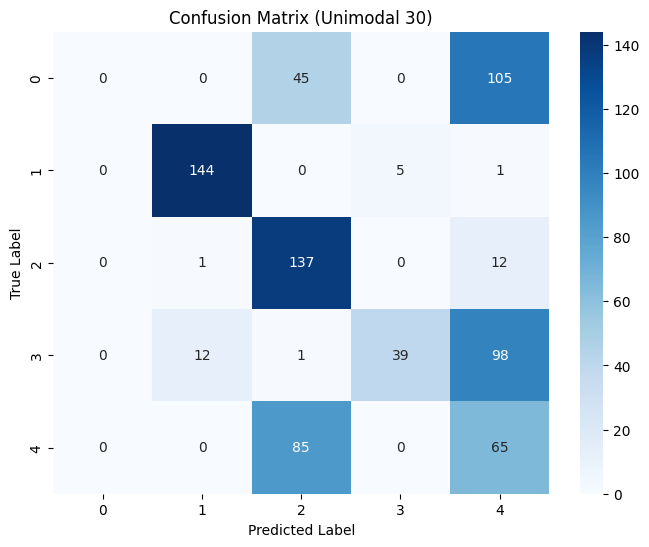

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize Confusion Matrix for Unimodal 30 Dataset
plt.figure(figsize=(8, 6))
sns.heatmap(cm_unimodal, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Unimodal 30)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

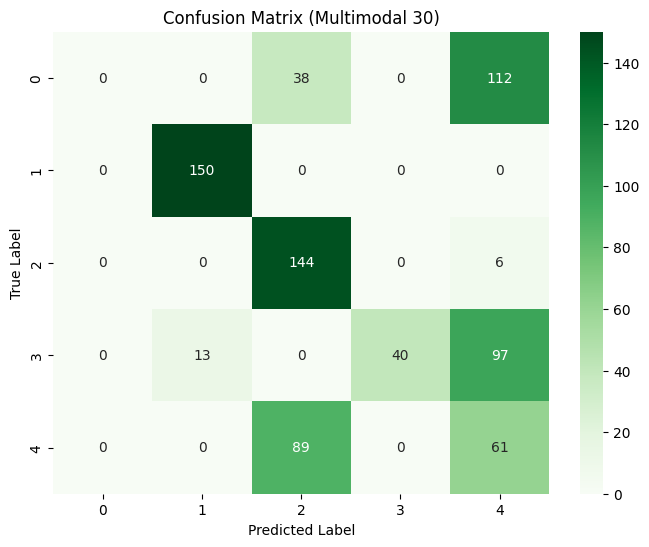

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize Confusion Matrix for Multimodal 30 Dataset
plt.figure(figsize=(8, 6))
sns.heatmap(cm_multimodal, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (Multimodal 30)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()